# CellxGene Census — Organ Data Explorer

Queries the CellxGene Census to assess what training data is available for new organs.
Checks cell counts, cell type annotation depth, and disease composition for each tissue.
Run this before downloading anything to decide what's worth using.

In [1]:
import cellxgene_census
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Tissues to evaluate — add more here as needed
TISSUES = [
    "liver",
    "lymph node",
    "kidney",
    "heart",
    "intestine",
    "pancreas",
    "skin of body",
    "bone marrow",
]

# For reference: current training data sizes
CURRENT = {
    "lung (training)": 2_282_447,
    "brain (training)": 888_263,
}

## 1. Cell Count Survey

For each tissue: total cells, normal-only cells, assay breakdown.

In [2]:
results = {}

with cellxgene_census.open_soma() as census:
    obs = census["census_data"]["homo_sapiens"].obs

    for tissue in TISSUES:
        print(f"Querying: {tissue} ...", end=" ", flush=True)
        try:
            df = obs.read(
                value_filter=f"tissue_general == '{tissue}' and is_primary_data == True",
                column_names=["tissue_general", "tissue", "disease", "cell_type", "assay", "sex", "development_stage"]
            ).concat().to_pandas()
            results[tissue] = df
            normal_n = (df["disease"] == "normal").sum()
            print(f"{len(df):,} total, {normal_n:,} normal")
        except Exception as e:
            print(f"ERROR: {e}")
            results[tissue] = pd.DataFrame()

print("\nDone.")

The "stable" release is currently 2025-11-08. Specify 'census_version="2025-11-08"' in future calls to open_soma() to ensure data consistency.


Querying: liver ... 1,625,338 total, 956,026 normal
Querying: lymph node ... 1,766,794 total, 919,426 normal
Querying: kidney ... 1,463,942 total, 658,049 normal
Querying: heart ... 3,104,821 total, 1,963,037 normal
Querying: intestine ... 374,931 total, 282,380 normal
Querying: pancreas ... 604,918 total, 425,161 normal
Querying: skin of body ... 844,129 total, 674,205 normal
Querying: bone marrow ... 915,689 total, 759,562 normal

Done.


## 2. Summary Table

In [3]:
rows = []
for tissue, df in results.items():
    if df.empty:
        rows.append({"tissue": tissue, "total_cells": 0, "normal_cells": 0,
                     "normal_pct": 0, "n_cell_types": 0, "n_assays": 0, "n_subtissues": 0})
        continue
    normal = df[df["disease"] == "normal"]
    rows.append({
        "tissue": tissue,
        "total_cells": len(df),
        "normal_cells": len(normal),
        "normal_pct": round(100 * len(normal) / len(df), 1),
        "n_cell_types": normal["cell_type"].nunique() if len(normal) else 0,
        "n_assays": df["assay"].nunique(),
        "n_subtissues": df["tissue"].nunique(),
    })

summary = pd.DataFrame(rows).sort_values("normal_cells", ascending=False)
summary["normal_cells"] = summary["normal_cells"].apply(lambda x: f"{x:,}")
summary["total_cells"] = summary["total_cells"].apply(lambda x: f"{x:,}")
summary.columns = ["Tissue", "Total cells", "Normal cells", "Normal %", "Cell types (normal)", "Assays", "Sub-tissues"]
print(summary.to_string(index=False))

      Tissue Total cells Normal cells  Normal %  Cell types (normal)  Assays  Sub-tissues
       heart   3,104,821    1,963,037      63.2                   84       8           19
       liver   1,625,338      956,026      58.8                  155      10            5
  lymph node   1,766,794      919,426      52.0                  118       8            8
 bone marrow     915,689      759,562      82.9                  129       9            1
skin of body     844,129      674,205      79.9                  127      11           27
      kidney   1,463,942      658,049      45.0                  152       9            6
    pancreas     604,918      425,161      70.3                   68       7            4
   intestine     374,931      282,380      75.3                  113       6            4


## 3. Normal-Cell Bar Chart

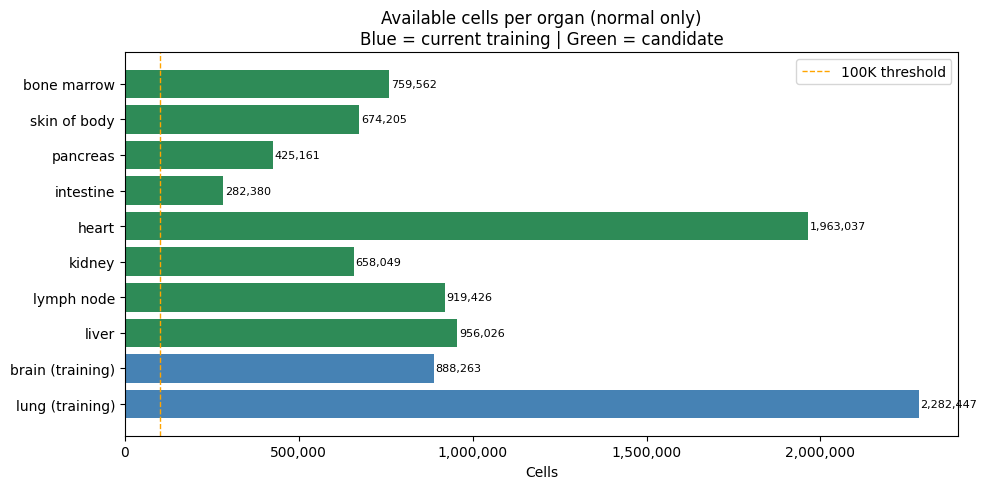

In [4]:
counts = {}
for tissue, df in results.items():
    if not df.empty:
        counts[tissue] = (df["disease"] == "normal").sum()
    else:
        counts[tissue] = 0

all_counts = {**CURRENT, **counts}
colors = ["steelblue" if t in CURRENT else "seagreen" for t in all_counts]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(list(all_counts.keys()), list(all_counts.values()), color=colors)
ax.set_xlabel("Cells")
ax.set_title("Available cells per organ (normal only)\nBlue = current training | Green = candidate")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.axvline(100_000, color="orange", linestyle="--", linewidth=1, label="100K threshold")
ax.legend()
for bar, val in zip(bars, all_counts.values()):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

## 4. Per-Tissue Deep Dive

For each tissue: top cell types, disease breakdown, assay breakdown.

In [5]:
TOP_N = 20  # cell types to show

for tissue, df in results.items():
    if df.empty:
        print(f"\n{'='*60}")
        print(f"  {tissue.upper()} — no data found")
        continue

    normal = df[df["disease"] == "normal"]

    print(f"\n{'='*60}")
    print(f"  {tissue.upper()}")
    print(f"  Total: {len(df):,}  |  Normal: {len(normal):,}  ({100*len(normal)/len(df):.0f}%)")

    print(f"\n  Top cell types (normal, n={len(normal):,}):")
    ct = normal["cell_type"].value_counts().head(TOP_N)
    for ctype, n in ct.items():
        bar = "█" * int(30 * n / ct.iloc[0])
        print(f"    {ctype:<45} {n:>7,}  {bar}")

    print(f"\n  Disease breakdown (all cells):")
    dis = df["disease"].value_counts().head(10)
    for d, n in dis.items():
        print(f"    {d:<45} {n:>7,}")

    print(f"\n  Assay breakdown (all cells):")
    for assay, n in df["assay"].value_counts().items():
        print(f"    {assay:<45} {n:>7,}")

    print(f"\n  Sub-tissue breakdown (normal):")
    for sub, n in normal["tissue"].value_counts().head(10).items():
        print(f"    {sub:<45} {n:>7,}")


  LIVER
  Total: 1,625,338  |  Normal: 956,026  (59%)

  Top cell types (normal, n=956,026):
    T cell                                        100,871  ██████████████████████████████
    macrophage                                     72,521  █████████████████████
    hepatoblast                                    69,987  ████████████████████
    natural killer cell                            60,290  █████████████████
    erythrocyte                                    58,282  █████████████████
    periportal region hepatocyte                   57,756  █████████████████
    erythroblast                                   46,008  █████████████
    hepatocyte                                     43,866  █████████████
    monocyte                                       40,063  ███████████
    epithelial cell                                39,670  ███████████
    hepatic stellate cell                          32,645  █████████
    centrilobular region hepatocyte                29,214  ████████

## 5. Lab Data Coverage Check

Check which lab cell types already exist verbatim (or close) in the Census annotations.
This shows what the model will need to distinguish vs. what's already in training vocabulary.

In [6]:
import scanpy as sc

LAB_FILES = {
    "Brain_normal": "lab-data/Brain_normal.h5ad",
    "Liver_normal": "lab-data/Liver_normal.h5ad",
    "Lymph_node_normal": "lab-data/Lymph_node_normal.h5ad",
    "lymphoid": "lab-data/lymphoid.h5ad",
    "myeloid": "lab-data/myeloid.h5ad",
}

# All Census cell types across queried tissues (normal only)
census_types = set()
for df in results.values():
    if not df.empty:
        census_types.update(df[df["disease"] == "normal"]["cell_type"].unique())

print(f"Total unique Census cell types (normal, across all queried tissues): {len(census_types)}")
print()

for name, path in LAB_FILES.items():
    try:
        adata = sc.read_h5ad(path, backed='r')
        lab_types = set(adata.obs["cell_type"].unique())
        # Normalize for fuzzy matching: lowercase, replace _ with space
        lab_norm = {t: t.lower().replace("_", " ") for t in lab_types}
        census_norm = {t.lower() for t in census_types}

        exact = {t for t, tn in lab_norm.items() if tn in census_norm}
        missing = lab_types - exact

        print(f"--- {name} ({len(lab_types)} types) ---")
        print(f"  Exact match in Census: {len(exact)}")
        for t in sorted(exact):
            print(f"    [MATCH]   {t}")
        print(f"  Not found (will need mapping or zero-shot): {len(missing)}")
        for t in sorted(missing):
            print(f"    [MISSING] {t}")
        print()
    except Exception as e:
        print(f"{name}: ERROR — {e}")

Total unique Census cell types (normal, across all queried tissues): 359

--- Brain_normal (15 types) ---
  Exact match in Census: 4
    [MATCH]   capillary_endothelial_cell
    [MATCH]   neuron
    [MATCH]   pericyte
    [MATCH]   smooth_muscle_cell
  Not found (will need mapping or zero-shot): 11
    [MISSING] GABAergic_interneuron
    [MISSING] GABAergic_interneuron_SST
    [MISSING] arterial_endothelial_cell
    [MISSING] astrocyte_fibrous_like
    [MISSING] astrocyte_protoplasmic
    [MISSING] meningeal_fibroblast
    [MISSING] oligodendrocyte
    [MISSING] oligodendrocyte_ISG_expressing
    [MISSING] oligodendrocyte_precursor_cell
    [MISSING] perivascular_fibroblast
    [MISSING] venous_endothelial_cell

--- Liver_normal (11 types) ---
  Exact match in Census: 3
    [MATCH]   cholangiocyte
    [MATCH]   hepatocyte
    [MATCH]   pericyte
  Not found (will need mapping or zero-shot): 8
    [MISSING] arterial_endothelial_cell
    [MISSING] endothelial_cell_proliferating
    [MISSI

## 6. Download Decision

Based on the above, decide which tissues to include in training.
Recommended threshold: **≥50K normal cells** with **≥10 annotated cell types**.

Modify `DOWNLOAD_TISSUES` below and run the next cell to fetch the h5ad files.

In [7]:
# Edit this list based on what you saw above
DOWNLOAD_TISSUES = [
    "liver",
    "lymph node",
    "bone marrow"
    # "kidney",
    # "heart",
    # add more as needed
]

OUTPUT_DIR = "census_data"
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Tissues to download:", DOWNLOAD_TISSUES)
print(f"Output directory: {OUTPUT_DIR}/")
print()
print("Estimated download sizes (normal cells only):")
for tissue in DOWNLOAD_TISSUES:
    df = results.get(tissue, pd.DataFrame())
    n = (df["disease"] == "normal").sum() if not df.empty else 0
    # Rough estimate: ~5KB per cell for sparse matrix
    est_mb = n * 5 / 1024
    print(f"  {tissue:<20} {n:>8,} cells  (~{est_mb:.0f} MB)")

Tissues to download: ['liver', 'lymph node', 'bone marrow']
Output directory: census_data/

Estimated download sizes (normal cells only):
  liver                 956,026 cells  (~4668 MB)
  lymph node            919,426 cells  (~4489 MB)
  bone marrow           759,562 cells  (~3709 MB)


In [ ]:
import cellxgene_census

with cellxgene_census.open_soma() as census:
    for tissue in DOWNLOAD_TISSUES:
        out_path = os.path.join(OUTPUT_DIR, f"{tissue.replace(' ', '_')}.h5ad")
        if os.path.exists(out_path):
            print(f"[SKIP] {out_path} already exists")
            continue

        print(f"Downloading {tissue} ...", flush=True)
        adata = cellxgene_census.get_anndata(
            census,
            organism="Homo sapiens",
            obs_value_filter=(
                f"tissue_general == '{tissue}' "
                f"and is_primary_data == True "
                f"and disease == 'normal'"
            ),
            obs_column_names=["cell_type", "tissue", "tissue_general", "disease",
                               "assay", "sex", "development_stage", "donor_id"],
        )
        print(f"  → {adata.n_obs:,} cells, {adata.n_vars:,} genes")
        print(f"  → {adata.obs['cell_type'].nunique()} cell types")
        print(f"  → Saving to {out_path} ...", flush=True)
        adata.write_h5ad(out_path)
        print(f"  → Done.")

print("\nAll downloads complete.")

The "stable" release is currently 2025-11-08. Specify 'census_version="2025-11-08"' in future calls to open_soma() to ensure data consistency.


  → 956,026 cells, 61,497 genes
  → 155 cell types
  → Saving to census_data/liver.h5ad ...
  → Done.
  → 919,426 cells, 61,497 genes
  → 118 cell types
  → Saving to census_data/lymph_node.h5ad ...
  → Done.
  → 759,562 cells, 61,497 genes
  → 129 cell types
  → Saving to census_data/bone_marrow.h5ad ...
  → Done.

All downloads complete.


: 

## 7. Post-Download Validation

Confirm what was downloaded and check annotation quality.

In [ ]:
import glob
import scanpy as sc

downloaded = sorted(glob.glob(os.path.join(OUTPUT_DIR, "*.h5ad")))
print(f"Downloaded files: {len(downloaded)}\n")

for path in downloaded:
    adata = sc.read_h5ad(path, backed='r')
    print(f"=== {os.path.basename(path)} ===")
    print(f"  Cells: {adata.n_obs:,}  |  Genes: {adata.n_vars:,}")
    print(f"  Cell types ({adata.obs['cell_type'].nunique()}):")
    cts = adata.obs["cell_type"].value_counts()
    for ct, n in cts.items():
        flag = "  ⚠ SMALL" if n < 50 else ""
        print(f"    {ct:<50} {n:>7,}{flag}")
    print(f"  Sub-tissues: {list(adata.obs['tissue'].unique())[:5]}")
    print(f"  Assays: {list(adata.obs['assay'].unique())}")
    print()